# Estimate of videos per CEO per year (global)

In [ ]:
%pip install pandas google-api-python-client matplotlib seaborn

## Get N random CEOs

In [ ]:
import json
import pandas as pd

N = 50

with open("data/ceos_2022.json") as f:
    ceo_list = json.load(f)

available = [
    x for x in ceo_list
    if not x["videos_collected"]
]

sampled = available[:N]

sampled_ceos = pd.DataFrame(sampled)

print(sampled_ceos.to_string())

## Get interviews published in 2022

In [ ]:
import os
import json
from dotenv import load_dotenv
from googleapiclient.discovery import build

load_dotenv()

youtube = build(
    "youtube",
    "v3",
    developerKey=os.getenv("YOUTUBE_API_KEY")
)

os.makedirs("output/estimation", exist_ok=True)

# Search + get details + save everything
if len(sampled_ceos) == 0:
    print("No new CEOs left to collect.")
else:
    for _, row in sampled_ceos.iterrows():
        ceo = row["CEO"]

        search_response = youtube.search().list(
            part="snippet",
            q=f"{ceo} interview",
            type="video",
            publishedAfter="2022-01-01T00:00:00Z",
            publishedBefore="2023-01-01T00:00:00Z",
            maxResults=50
        ).execute()

        video_ids = [
            item["id"]["videoId"]
            for item in search_response["items"]
        ]

        details_response = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=",".join(video_ids)
        ).execute()

        output = {
            "ceo": ceo,
            "search_results": search_response,
            "video_details": details_response
        }

        with open(f"output/estimation/{ceo}.json", "w") as f:
            json.dump(output, f, indent=2)


        # Update ceos_2022.json immediately after success
        with open("ceos_2022.json") as f:
            ceo_list = json.load(f)

        for c in ceo_list:
            if c["CEO"] == ceo:
                c["videos_collected"] = True
                break

        with open("ceos_2022.json", "w") as f:
            json.dump(ceo_list, f, indent=2)

        print(f"Completed: {ceo}")

## Statistics (general videos - unprocessed)

In [57]:
import os
import json

folder = "output/estimation"
num_files = 0
total_videos = 0

for file in os.listdir(folder):
    if file.endswith(".json"):
        num_files += 1

        with open(os.path.join(folder, file)) as f:
            data = json.load(f)

        total_videos += len(data["video_details"]["items"])

print("Number of CEOs:", num_files)
print("Total videos collected:", total_videos)

Number of CEOs: 93
Total videos collected: 3163


## Post-process videos to verify CEO name is in the title

In [ ]:
import os
import json
import re

GENERAL_DIR = "output/estimation"
POSTPROCESSED_DIR = "output/estimation/postprocessed"

os.makedirs(POSTPROCESSED_DIR, exist_ok=True)

def name_in_title(name, title):
    """Case-insensitive check that the CEO's name appears in the title."""
    if not title:
        return False
    return name.lower() in title.lower()

for file in os.listdir(GENERAL_DIR):
    if not file.endswith(".json"):
        continue

    filepath = os.path.join(GENERAL_DIR, file)
    if not os.path.isfile(filepath):
        continue

    with open(filepath) as f:
        data = json.load(f)

    ceo = data["ceo"]

    # Filter video_details items: keep only those with the CEO name in the title
    original_items = data.get("video_details", {}).get("items", [])
    filtered_items = [
        video for video in original_items
        if name_in_title(ceo, video.get("snippet", {}).get("title", ""))
    ]

    kept_video_ids = {video["id"] for video in filtered_items}

    # Also filter search_results items to keep them consistent with video_details
    original_search_items = data.get("search_results", {}).get("items", [])
    filtered_search_items = [
        item for item in original_search_items
        if item.get("id", {}).get("videoId") in kept_video_ids
    ]

    # Build the new output, preserving structure but with filtered items
    new_data = dict(data)  # shallow copy of top-level keys (ceo, query, etc.)

    new_data["search_results"] = dict(data.get("search_results", {}))
    new_data["search_results"]["items"] = filtered_search_items

    new_data["video_details"] = dict(data.get("video_details", {}))
    new_data["video_details"]["items"] = filtered_items

    with open(os.path.join(POSTPROCESSED_DIR, file), "w") as f:
        json.dump(new_data, f, indent=2)

    print(f"{ceo}: kept {len(filtered_items)}/{len(original_items)} videos")

## Statistics

In [83]:
import os
import json

folder = "output/estimation/postprocessed"
num_files = 0
total_videos = 0

for file in os.listdir(folder):
    if file.endswith(".json"):
        num_files += 1

        with open(os.path.join(folder, file)) as f:
            data = json.load(f)

        total_videos += len(data["video_details"]["items"])

print("Number of CEOs:", num_files)
print("Total videos collected:", total_videos)

Number of CEOs: 93
Total videos collected: 231


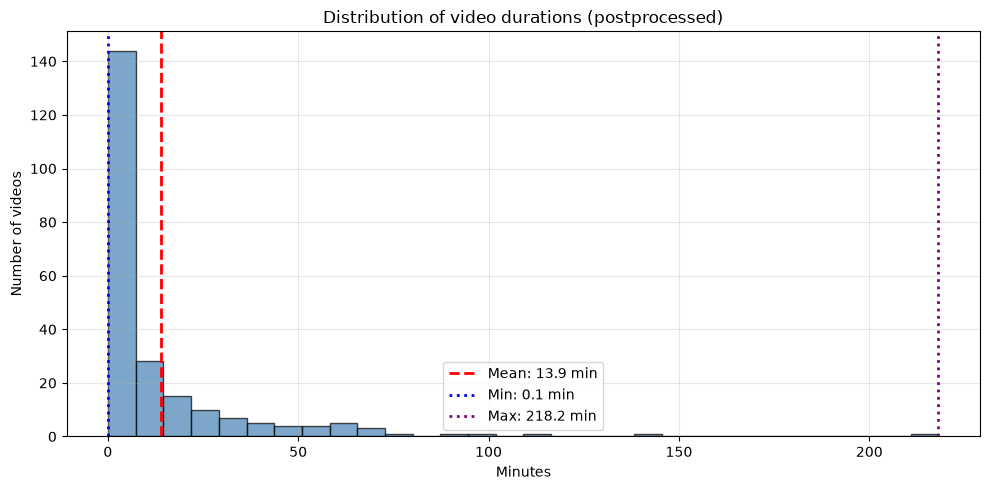

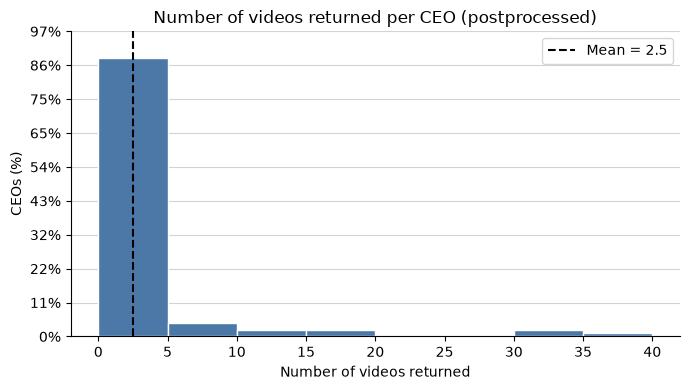

In [85]:
import os
import json
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def duration_to_seconds(duration):
    hours = re.search(r"(\d+)H", duration)
    minutes = re.search(r"(\d+)M", duration)
    seconds = re.search(r"(\d+)S", duration)

    return (
        (int(hours.group(1)) * 3600 if hours else 0) +
        (int(minutes.group(1)) * 60 if minutes else 0) +
        (int(seconds.group(1)) if seconds else 0)
    )

GENERAL_OUTPUT_DIR = "output/estimation/postprocessed"

# collect individual video durations + videos-per-CEO counts
all_durations = []
video_counts = []

for file in os.listdir(GENERAL_OUTPUT_DIR):
    if file.endswith(".json"):
        with open(f"{GENERAL_OUTPUT_DIR}/{file}") as f:
            data = json.load(f)

        items = data["video_details"]["items"]
        video_counts.append(len(items))

        for video in items:
            duration = duration_to_seconds(video["contentDetails"]["duration"]) / 60
            all_durations.append(duration)

# Plot 1: video duration
mean_duration = np.mean(all_durations)
min_duration = np.min(all_durations)
max_duration = np.max(all_durations)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(all_durations, bins=30, edgecolor='black', alpha=0.7, color='steelblue')

ax.axvline(mean_duration, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_duration:.1f} min')
ax.axvline(min_duration, color='blue', linestyle=':', linewidth=2, label=f'Min: {min_duration:.1f} min')
ax.axvline(max_duration, color='purple', linestyle=':', linewidth=2, label=f'Max: {max_duration:.1f} min')

ax.set_xlabel('Minutes')
ax.set_ylabel('Number of videos')
ax.set_title('Distribution of video durations (postprocessed)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: number of videos per CEO
plt.figure(figsize=(7, 4))
counts, bins, patches = plt.hist(
    video_counts,
    bins=range(0, max(video_counts) + 5, 5),
    color="#4c78a8",
    edgecolor="white"
)
total = len(video_counts)
plt.gca().set_yticks(
    plt.gca().get_yticks()
)
plt.gca().set_yticklabels(
    [f"{y/total*100:.0f}%" for y in plt.gca().get_yticks()]
)
plt.axvline(
    np.mean(video_counts),
    color="black",
    linestyle="--",
    label=f"Mean = {np.mean(video_counts):.1f}"
)
plt.xlabel("Number of videos returned")
plt.ylabel("CEOs (%)")
plt.title("Number of videos returned per CEO (postprocessed)")
ax = plt.gca()
ax.set_axisbelow(True)
plt.grid(
    axis="y",
    color="lightgrey",
    linewidth=0.8
)
plt.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Estimation for the same CEOs but only DEI-related videos

In [ ]:
import os
import json
from dotenv import load_dotenv
from googleapiclient.discovery import build

load_dotenv()
youtube = build("youtube", "v3", developerKey=os.getenv("YOUTUBE_API_KEY_2"))

DEI_KEYWORDS = [
    "diversity",
    "inclusion",
    "equity",
    "DEI",
    "belonging",
    "LGBTQ",
    "inclusive",
    "social responsibility"
]

CEOS_PATH = "data/ceos_2022.json"
OUTPUT_DIR = "output/estimation/dei"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load CEO list and figure out who's eligible for DEI collection:
# general videos already collected, DEI videos not yet collected
with open(CEOS_PATH) as f:
    ceo_list = json.load(f)

eligible_ceos = [
    c["CEO"] for c in ceo_list
    if c.get("general_videos_collected") and not c.get("dei_videos_collected")
]

# Build the "OR" keyword clause once, e.g. (diversity OR inclusion OR ...)
keywords_clause = " OR ".join(DEI_KEYWORDS)

if len(eligible_ceos) == 0:
    print("No new CEOs left to collect.")
else:
    for ceo in eligible_ceos:
        query = f"{ceo} ({keywords_clause})"

        search_response = youtube.search().list(
            part="snippet",
            q=query,
            type="video",
            publishedAfter="2022-01-01T00:00:00Z",
            publishedBefore="2023-01-01T00:00:00Z",
            maxResults=50
        ).execute()

        video_ids = [
            item["id"]["videoId"]
            for item in search_response["items"]
        ]

        details_response = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=",".join(video_ids)
        ).execute() if video_ids else {"items": []}

        output = {
            "ceo": ceo,
            "query": query,
            "search_results": search_response,
            "video_details": details_response
        }

        with open(f"{OUTPUT_DIR}/{ceo}.json", "w") as f:
            json.dump(output, f, indent=2)

        # Update ceos_2022.json immediately after success
        with open(CEOS_PATH) as f:
            ceo_list = json.load(f)

        for c in ceo_list:
            if c["CEO"] == ceo:
                c["dei_videos_collected"] = True
                break

        with open(CEOS_PATH, "w") as f:
            json.dump(ceo_list, f, indent=2)

        print(f"Completed: {ceo}")

## Statistics (DEI videos - unprocessed)

In [76]:
import os
import json

folder = "output/estimation/dei"
num_files = 0
total_videos = 0

for file in os.listdir(folder):
    if file.endswith(".json"):
        num_files += 1

        with open(os.path.join(folder, file)) as f:
            data = json.load(f)

        total_videos += len(data["video_details"]["items"])

print("Number of CEOs:", num_files)
print("Total videos collected:", total_videos)

Number of CEOs: 93
Total videos collected: 1663


## Post-process videos to verify CEO name is in the title

In [ ]:
import os
import json
import re

DEI_DIR = "output/estimation/dei"
POSTPROCESSED_DIR = "output/estimation/dei/postprocessed"

os.makedirs(POSTPROCESSED_DIR, exist_ok=True)

def name_in_title(name, title):
    """Case-insensitive check that the CEO's name appears in the title."""
    if not title:
        return False
    return name.lower() in title.lower()

for file in os.listdir(DEI_DIR):
    if not file.endswith(".json"):
        continue

    filepath = os.path.join(DEI_DIR, file)
    with open(filepath) as f:
        data = json.load(f)

    ceo = data["ceo"]

    # Filter video_details items: keep only those with the CEO name in the title
    original_items = data.get("video_details", {}).get("items", [])
    filtered_items = [
        video for video in original_items
        if name_in_title(ceo, video.get("snippet", {}).get("title", ""))
    ]

    kept_video_ids = {video["id"] for video in filtered_items}

    # Also filter search_results items to keep them consistent with video_details
    original_search_items = data.get("search_results", {}).get("items", [])
    filtered_search_items = [
        item for item in original_search_items
        if item.get("id", {}).get("videoId") in kept_video_ids
    ]

    # Build the new output, preserving structure but with filtered items
    new_data = dict(data)  # shallow copy of top-level keys (ceo, query, etc.)

    new_data["search_results"] = dict(data.get("search_results", {}))
    new_data["search_results"]["items"] = filtered_search_items

    new_data["video_details"] = dict(data.get("video_details", {}))
    new_data["video_details"]["items"] = filtered_items

    with open(os.path.join(POSTPROCESSED_DIR, file), "w") as f:
        json.dump(new_data, f, indent=2)

    print(f"{ceo}: kept {len(filtered_items)}/{len(original_items)} videos")

## Statistics (DEI videos - processed)

In [79]:
import os
import json

folder = "output/estimation/dei/postprocessed"
num_files = 0
total_videos = 0

for file in os.listdir(folder):
    if file.endswith(".json"):
        num_files += 1

        with open(os.path.join(folder, file)) as f:
            data = json.load(f)

        total_videos += len(data["video_details"]["items"])

print("Number of CEOs:", num_files)
print("Total videos collected:", total_videos)

Number of CEOs: 93
Total videos collected: 18


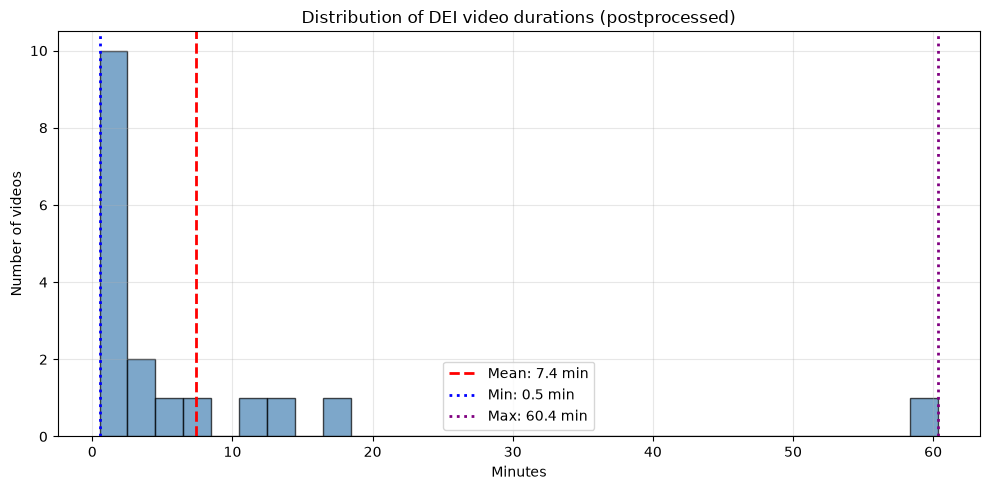

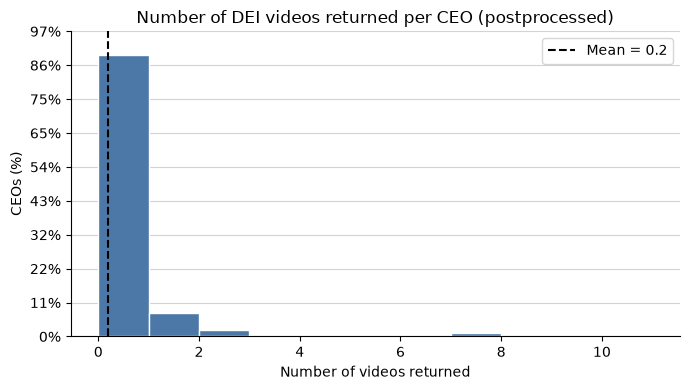

In [81]:
import os
import json
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def duration_to_seconds(duration):
    hours = re.search(r"(\d+)H", duration)
    minutes = re.search(r"(\d+)M", duration)
    seconds = re.search(r"(\d+)S", duration)

    return (
        (int(hours.group(1)) * 3600 if hours else 0) +
        (int(minutes.group(1)) * 60 if minutes else 0) +
        (int(seconds.group(1)) if seconds else 0)
    )

DEI_OUTPUT_DIR = "output/estimation/dei/postprocessed"

# collect individual video durations + videos-per-CEO counts
all_durations = []
video_counts = []

for file in os.listdir(DEI_OUTPUT_DIR):
    if file.endswith(".json"):
        with open(f"{DEI_OUTPUT_DIR}/{file}") as f:
            data = json.load(f)

        items = data["video_details"]["items"]
        video_counts.append(len(items))

        for video in items:
            duration = duration_to_seconds(video["contentDetails"]["duration"]) / 60
            all_durations.append(duration)

# Plot 1: video duration
mean_duration = np.mean(all_durations)
min_duration = np.min(all_durations)
max_duration = np.max(all_durations)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(all_durations, bins=30, edgecolor='black', alpha=0.7, color='steelblue')

ax.axvline(mean_duration, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_duration:.1f} min')
ax.axvline(min_duration, color='blue', linestyle=':', linewidth=2, label=f'Min: {min_duration:.1f} min')
ax.axvline(max_duration, color='purple', linestyle=':', linewidth=2, label=f'Max: {max_duration:.1f} min')

ax.set_xlabel('Minutes')
ax.set_ylabel('Number of videos')
ax.set_title('Distribution of DEI video durations (postprocessed)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: number of videos per CEO
plt.figure(figsize=(7, 4))
counts, bins, patches = plt.hist(
    video_counts,
    bins=range(0, max(video_counts) + 5, 1),
    color="#4c78a8",
    edgecolor="white"
)
total = len(video_counts)
plt.gca().set_yticks(
    plt.gca().get_yticks()
)
plt.gca().set_yticklabels(
    [f"{y/total*100:.0f}%" for y in plt.gca().get_yticks()]
)
plt.axvline(
    np.mean(video_counts),
    color="black",
    linestyle="--",
    label=f"Mean = {np.mean(video_counts):.1f}"
)
plt.xlabel("Number of videos returned")
plt.ylabel("CEOs (%)")
plt.title("Number of DEI videos returned per CEO (postprocessed)")
ax = plt.gca()
ax.set_axisbelow(True)
plt.grid(
    axis="y",
    color="lightgrey",
    linewidth=0.8
)
plt.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()